## Title: Working with pandas Data Frames (Heterogeneous Data)
#### Hello my name is **Vidar** (undergraduate student SIT220)
My student ID is **225042826** and my email is **s225042826@deakin.edu.au**

#### Abstract:

This notebook report analyses hourly meteorological data recorded at three NY airports in 2013 (LGA,JFK and EWR).
The dataset contains weather variables like temperature, wind_speed and precipitation etc..
The objective of this analysis is to convert all the weather variables into metric units, compute daily mean wind speeds for LaGuardia Airport (LGA), plot and visualise the results and then identify the 10 windiest days of the year

We will begin with data loading and preprocessing (R statement at the top of the csv), followed by conversion, aggregation and visualisation.

## 1. Loading Dataset and Importing packages

The dataset is loaded into a pandas DataFrame. However during the initial attempt at reading the csv, an error happened because of comment lines at the beginning of the CSV. To reslve the issue, the 'comment = "#"' parameter told pandas to ignore all lines beginning with a comment symbol. 

After loading the dataset, I made sure that the structure and contents were right with info() and describe().

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

weather = pd.read_csv("weather.csv", comment = '#')
weather.head()

weather.info()
weather.describe()





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26130 entries, 0 to 26129
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   origin      26130 non-null  object 
 1   year        26130 non-null  int64  
 2   month       26130 non-null  int64  
 3   day         26130 non-null  int64  
 4   hour        26130 non-null  int64  
 5   temp        26129 non-null  float64
 6   dewp        26129 non-null  float64
 7   humid       26129 non-null  float64
 8   wind_dir    25712 non-null  float64
 9   wind_speed  26127 non-null  float64
 10  wind_gust   26127 non-null  float64
 11  precip      26130 non-null  float64
 12  pressure    23400 non-null  float64
 13  visib       26130 non-null  float64
 14  time_hour   26130 non-null  object 
dtypes: float64(9), int64(4), object(2)
memory usage: 3.0+ MB


,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib
count,26130.0,26130.000000,26130.000000,26130.000000,26129.000000,26129.000000,26129.000000,25712.000000,26127.000000,26127.000000,26130.000000,23400.000000,26130.000000
mean,2013.0,6.505741,15.679717,11.518408,55.203515,41.385399,62.347322,198.066661,10.395868,11.963357,0.002726,1017.895175,9.204828
std,0.0,3.440031,8.765022,6.916581,17.782124,19.371649,19.196078,107.841624,8.521200,9.806027,0.019665,7.422790,2.136306
min,2013.0,1.000000,1.000000,0.000000,10.940000,-9.940000,12.740000,0.000000,0.000000,0.000000,0.000000,983.800000,0.000000
25%,2013.0,4.000000,8.000000,6.000000,39.920000,26.060000,46.990000,120.000000,6.904680,7.945768,0.000000,1012.900000,10.000000
50%,2013.0,7.000000,16.000000,12.000000,55.040000,42.080000,61.660000,220.000000,9.206240,10.594357,0.000000,1017.600000,10.000000
75%,2013.0,9.000000,23.000000,18.000000,69.980000,57.920000,78.620000,290.000000,13.809360,15.891535,0.000000,1023.000000,10.000000
max,2013.0,12.000000,31.000000,23.000000,100.040000,78.080000,100.000000,360.000000,1048.360580,1206.432388,1.180000,1042.100000,10.000000


## 2. Conversion of Units

The dataset is originally recorded in imperial units. But in order to maintain consistency and to follow the task sheet, we convert it to International System of Units (SI). We converted:

* Temperature from Fahrenheit to Celsius
* Wind speed and gust speed from mph to m/s
* Precipitation from inches to mm
* Visibility from miles to metres

And the existing columsn are directly overwritten to keep the dataset clean.


In [5]:
weather["temp"] = (weather["temp"] - 32) * 5/9
weather["temp"] = (weather["temp"] - 32) * 5/9

weather["precip"] = weather["precip"] * 25.4

weather["visib"] = weather["visib"] * 1609.34

weather["wind_speed"] = weather["wind_speed"] * 0.44704

weather["wind_gust"] = weather["wind_gust"] * 0.44704

weather.head()


,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,time_hour
0,EWR,2013,1,1,0,-16.222222,21.92,53.97,230.0,4.630002,5.328114,0.0,1013.9,16093.4,2013-01-01 01:00:00
1,EWR,2013,1,1,1,-16.222222,21.92,53.97,230.0,6.173336,7.104152,0.0,1013.0,16093.4,2013-01-01 02:00:00
2,EWR,2013,1,1,2,-15.944444,21.92,52.09,230.0,5.658892,6.512139,0.0,1012.6,16093.4,2013-01-01 03:00:00
3,EWR,2013,1,1,3,-15.944444,23.00,54.51,230.0,6.173336,7.104152,0.0,1012.7,16093.4,2013-01-01 04:00:00
4,EWR,2013,1,1,4,-15.944444,24.08,57.04,240.0,6.687781,7.696165,0.0,1012.8,16093.4,2013-01-01 05:00:00


All the weather variables have now been converted into metric units as we can see with head(), the dataset is now standardised.

Personal review (optional): I learnt how to convert a lot of metrics here, as I've always learned *SI*

## 3. Computing Daily Mean Wind Speeds at LGA

Here we need to compute daily mean wind speeds for LGA, the data is first filtered to only show records from LGA. 
Then, the dataset is grouped by year, month and day.
A proper datetime column is the created to help with plotting and other analysis.

*Personal Comment: the 5th line was added after plotting to ensure the index was truely the date

In [7]:
LGA = weather[weather["origin"] == "LGA"]

daily_wind_speed = (LGA.groupby(["year","month","day"])["wind_speed"].mean().reset_index())

print(daily_wind_speed)

daily_wind_speed["date"] = pd.to_datetime(daily_wind_speed[["year","month","day"]])

daily_wind_speed = daily_wind_speed.set_index("date") # added this line after making the plot because now we can see the dates under the plot because date is set as index

daily_wind_speed.head()
daily_wind_speed.shape

     year  month  day  wind_speed
0    2013      1    1    6.687781
1    2013      1    2    6.430559
2    2013      1    3    4.908660
3    2013      1    4    6.880698
4    2013      1    5    5.144447
..    ...    ...  ...         ...
359  2013     12   26    3.301020
360  2013     12   27    5.401669
361  2013     12   28    4.672873
362  2013     12   29    3.794030
363  2013     12   30    6.001855

[364 rows x 4 columns]


(364, 4)

*Personal Comment: Initially the date column was created but it wasn't set as the DataFrame index, this caused issue for plotting, because the x-axis did not display calendar dates such as the representative plot in the task sheet ("2013-06"). But after setting the date column as the index, it all worked.*

## 4. Visualising Daily Wind Speeds

The daily mean wind speeds are visualised to observe how wind conditions varied throughout 2013 at LGA

The x-axis represents the date and y-axis shows the daily average wind speed in m/s at LGA.

We can see that I added daily_wind_speed.index to set the datetime properly for the x-axis.

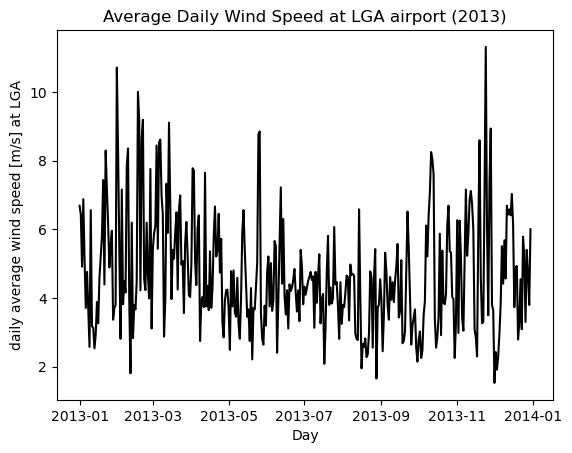

In [9]:
plt.plot(daily_wind_speed.index, daily_wind_speed["wind_speed"],color = 'black')

plt.title("Average Daily Wind Speed at LGA airport (2013)")
plt.xlabel("Day")
plt.ylabel("daily average wind speed [m/s] at LGA")
plt.show()

The plot shows some variability in wind speed throughout the year.
From what I see the higher wind speeds appear during February and December. 
During the middle of the year the wind speeds are relatively calmer.

## 5. Identifying the Ten Windiest Days.

To identify the ten windiest days at LGA, I sorted the daily mean wind speeds in desceding order (ascending = False).

The top 10 values will be the dates with the strongest wind activity.

In [15]:
ten_windiest_days = (daily_wind_speed[["wind_speed"]].sort_values(by = "wind_speed", ascending = False))

ten_windiest_days.head(10)

ten_windiest_days




,wind_speed
date,
2013-11-24,11.317783
2013-01-31,10.717598
2013-02-17,10.010236
2013-02-21,9.192903
2013-02-18,9.174264
...,...
2013-08-16,1.945943
2013-12-03,1.907732
2013-02-11,1.800556


I displayed the ten days with the highest recorded daily mean wind speeds in 2013 at LGA

And most of these days they appear during the December - March period which in New York is the winter period which is logical in retrospective.

## Optional 1 - Identify missing temps readings at JFK

We first need to filter the data to include only JFK airport and we need to create a proper date time column using the year month day and hour fields.
Missing values include:

- NaN temperature values
- timestamps that are completely absent

Then, we create the full time index for 2013, so every month,day,hour of 2013.
There should be 8760 hours in 2013 [Source: Random guy's computation on Quora](https://www.quora.com/What-is-the-approximate-number-of-hours-in-a-year)
Furthermore, we need to find hte missing timestamps with difference() method that compares it to the index of jfk datetime column, eg: finding rows that were never recorded at all.
We find the explicit missing temperature values with isna() method.


In [71]:
jfk = weather[weather["origin"] == "JFK"].copy()

jfk["datetime"] =pd.to_datetime(jfk[["year","month","day","hour"]])
jfk = jfk.set_index("datetime").sort_index()

whole_time = pd.date_range(start = "2013-01-01 00:00:00",end = "2013-12-31 23:00:00", freq = "H")

missing_timestamps = whole_time.difference(jfk.index)
explicit_missing_temp = jfk[jfk["temp"].isna()]

print("Expected hours in 2013:", len(whole_time))
print("rows present for JFK:", len(jfk))
print("Omitted timestamps:",len(missing_timestamps))
print("Explicit missing temperatures:", explicit_missing_temp)

missing_timestamps[:10]

Expected hours in 2013: 8760
rows present for JFK: 8711
Omitted timestamps: 49
Explicit missing temperatures: Empty DataFrame
Columns: [origin, year, month, day, hour, temp, dewp, humid, wind_dir, wind_speed, wind_gust, precip, pressure, visib, time_hour]
Index: []


DatetimeIndex(['2013-01-01 05:00:00', '2013-02-21 05:00:00',
               '2013-03-05 06:00:00', '2013-03-31 01:00:00',
               '2013-04-03 00:00:00', '2013-08-13 04:00:00',
               '2013-08-16 04:00:00', '2013-08-19 21:00:00',
               '2013-08-22 22:00:00', '2013-08-23 00:00:00'],
              dtype='datetime64[ns]', freq=None)

From the results ,we can see that there are no explicit NaN temperature values but there are 49 omitted hourly records.
So, all the missing data comes from omitted rows, not from NaN cells. The temperature column has no missing vlaues, but the dataset is incomplete because 49 hourly timestamps are absent.

## Optional 2 and 3 - Adding the missing records and computing daily average temperatures by linearly interpolating

We should insert the missing timestamps in the dataset.
First we reindex the jfk to the whole date_range (see above) to create our variable jfk_whole that has every single temperature readings from every hours of 2013.
We compute the daily average with interpolation and without.

> I do have to talk about interpolation which fills missing values by estimating them based on the preceding and following valid observations, creating a smoother and more continuous time series. 

In [97]:
jfk_whole = jfk.reindex(whole_time)
jfk_whole.head()

jfk_whole["temp_interpolated"] = jfk_whole["temp"].interpolate(method="linear")

# Daily Average without interpolation
daily_temp_omitted = (jfk_whole["temp"].resample("D").mean())

# Daily Average with interpolation
daily_temp_interpolated = (jfk_whole["temp_interpolated"].resample("D").mean())



## Optional 4 - Plot Comparison

The following plot compares daily average temps calculated using the omitted approach vs the interpolation
This visual comparison helps determine whether the interpolation process actually alters the results.


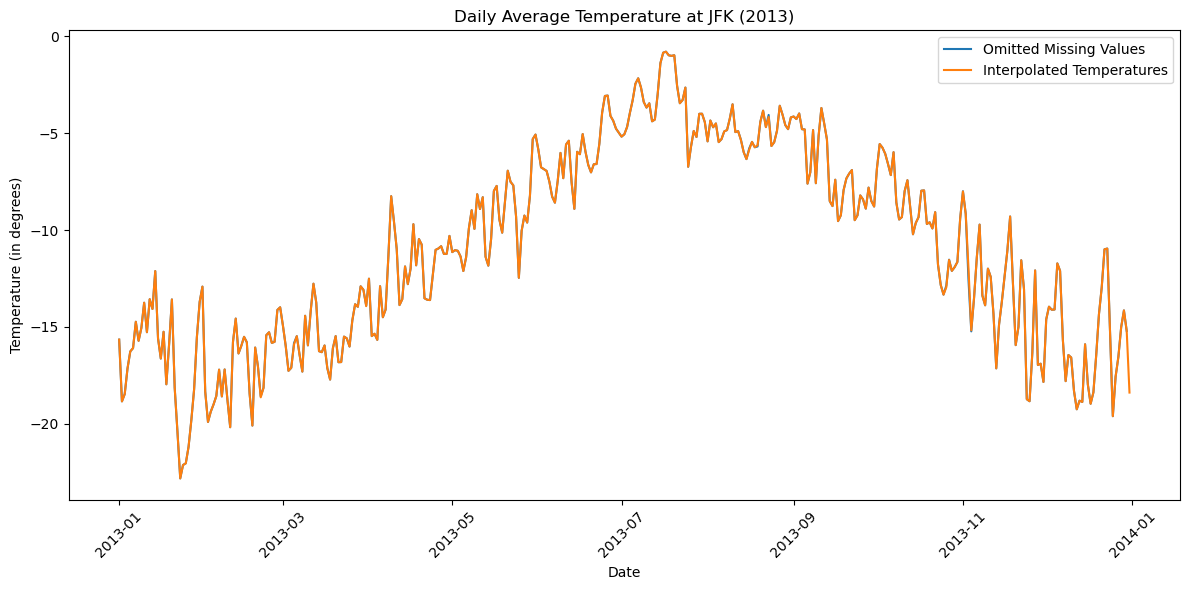

In [93]:
plt.figure(figsize=(12,6))

plt.plot(daily_temp_omitted.index, daily_temp_omitted, label = "Omitted Missing Values")
plt.plot(daily_temp_omitted.index, daily_temp_interpolated, label = "Interpolated Temperatures")

plt.title("Daily Average Temperature at JFK (2013)")
plt.xlabel("Date")
plt.ylabel("Temperature (in degrees)")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

The comparison shows that the two daily average curves are identical, showing that the 49 omitted hourly records had minimal impact on daily aggregated values.

This suggests that while the dataset wakind of y incomplete at hourly resolution, the overall daily temperature trends remain largely unaffectedsis.

## Conclusion

This analysis converted all the weather variables into metric units and calculated daily mean wind speeds for LGA in New York

The visualisation revealed seasonal variability (wind speeds depend on the period/season), with stronger winds happening during winter months.
Additionally, the ten windiest days were identified through sorting of daily averages with **sort_values()**

One challenge encountered during the analysis was related to datetime, Setting the date column that we created as the index was essential.

Overall:

- this task demonstrates the importance of loading the data and processing it carefully (as the CSV wasn't entirely clean)
- the importance of unit standardisation and aggregation with time-series dataset.